In [53]:
!pip install joblib

In [22]:
# ==========================
# Import Required Libraries
# ==========================

# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Natural Language Processing (NLP)
import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

In [23]:
# ==========================
# Download NLTK Resources
# ==========================

nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\SHUBHAM\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SHUBHAM\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [24]:
# ==========================
# Load the Dataset
# ==========================

# Read the CSV file
df = pd.read_csv("Tweets.csv", encoding="latin-1") #Sometimes Twitter datasets contain emojis or special characters.

# Display the first 5 rows
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [25]:
# ==========================
# Explore the Dataset
# ==========================

# Display column names
print("Columns in the dataset:\n")
print(df.columns)

# Display dataset shape
print("\nDataset Shape:")
print(df.shape)

# Display information about the dataset
print("\nDataset Information:")
df.info()

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

Columns in the dataset:

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')

Dataset Shape:
(14640, 15)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_s

In [26]:
# ==========================
# Keep Only Required Columns
# ==========================

# Select only the required columns
df = df[["text", "airline_sentiment"]]

# Rename the columns
df.columns = ["tweet", "sentiment"]

# Display first 5 rows
df.head()

,tweet,sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


In [42]:
# ==========================
# Stop Words
# ==========================

from nltk.corpus import stopwords

# Load English stop words
stop_words = set(stopwords.words("english"))

# Keep important negation words
stop_words.discard("not")
stop_words.discard("no")
stop_words.discard("never")

print("Stop words loaded successfully!")
print("'not' in stop words? ", "not" in stop_words)
print("'no' in stop words? ", "no" in stop_words)
print("'never' in stop words? ", "never" in stop_words)

Stop words loaded successfully!
'not' in stop words?  False
'no' in stop words?  False
'never' in stop words?  False


In [28]:
# ==========================
# Function to Clean Tweets
# ==========================

def clean_tweet(tweet):

    # Convert text to lowercase
    tweet = tweet.lower()

    # Remove URLs
    tweet = re.sub(r'http\S+|www\S+', '', tweet)

    # Remove Twitter mentions (@username)
    tweet = re.sub(r'@\w+', '', tweet)

    # Remove the '#' symbol
    tweet = tweet.replace("#", "")

    # Remove punctuation
    tweet = tweet.translate(str.maketrans("", "", string.punctuation))

    # Remove numbers
    tweet = re.sub(r'\d+', '', tweet)

    # Split sentence into words
    words = word_tokenize(tweet)

    # Remove stop words
    words = [word for word in words if word not in stop_words]

    # Join words back into a sentence
    tweet = " ".join(words)

    return tweet

In [29]:
# ==========================
# Clean All Tweets
# ==========================

# Apply the cleaning function to every tweet
df["clean_tweet"] = df["tweet"].apply(clean_tweet)

# Display original and cleaned tweets
df[["tweet", "clean_tweet"]].head()

,tweet,clean_tweet
0,@VirginAmerica What @dhepburn said.,said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials experience tacky
2,@VirginAmerica I didn't today... Must mean I n...,didnt today must mean need take another trip
3,@VirginAmerica it's really aggressive to blast...,really aggressive blast obnoxious entertainmen...
4,@VirginAmerica and it's a really big bad thing...,really big bad thing


In [43]:
# ==========================
# TF-IDF Vectorization
# ==========================

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X = tfidf.fit_transform(df["clean_tweet"])

y = df["sentiment"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (14640, 5000)
Target Shape : (14640,)


In [44]:
# ==========================
# Split Dataset into Training and Testing Sets
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

Training Data Shape : (11712, 5000)
Testing Data Shape  : (2928, 5000)


In [45]:
# ==========================
# Train Logistic Regression Model
# ==========================

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [46]:
y_pred = lr_model.predict(X_test)

In [47]:
# ==========================
# Calculate Accuracy
# ==========================
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy*100)

Accuracy : 79.6448087431694


In [48]:
# ==========================
# Classification Report
# ==========================

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.81      0.94      0.87      1889
     neutral       0.68      0.46      0.55       580
    positive       0.82      0.62      0.70       459

    accuracy                           0.80      2928
   macro avg       0.77      0.67      0.71      2928
weighted avg       0.79      0.80      0.78      2928



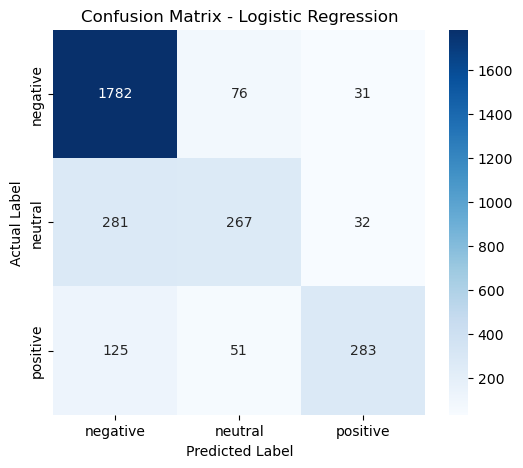

In [49]:
# ==========================
# Confusion Matrix
# ==========================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=lr_model.classes_,
    yticklabels=lr_model.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [50]:
# ==========================
# Predict Sentiment of New Tweet
# ==========================

def predict_sentiment(tweet):

    # Clean the tweet
    cleaned = clean_tweet(tweet)

    # Convert to TF-IDF
    vector = tfidf.transform([cleaned])

    # Predict
    prediction = lr_model.predict(vector)

    return prediction[0]

In [51]:
# ==========================
# User Input
# ==========================

tweet = input("Enter a Tweet: ")

result = predict_sentiment(tweet)

print("\nPredicted Sentiment :", result)

Enter a Tweet:  it is not bad air



Predicted Sentiment : negative


In [41]:
while True:

    tweet = input("\nEnter Tweet (or type 'exit' to quit): ")

    if tweet.lower() == "exit":
        break

    print("Predicted Sentiment :", predict_sentiment(tweet))


Enter Tweet (or type 'exit' to quit):  better air


Predicted Sentiment : negative



Enter Tweet (or type 'exit' to quit):  wxit


Predicted Sentiment : negative



Enter Tweet (or type 'exit' to quit):  exit


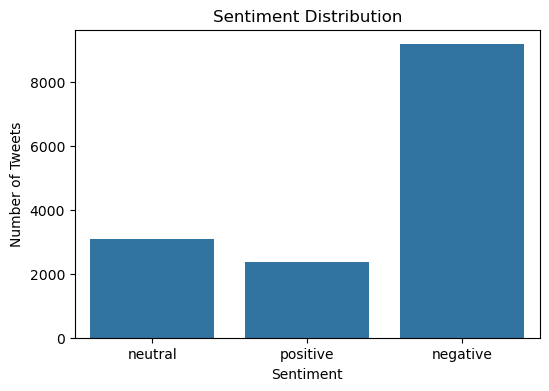

In [52]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="sentiment"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()

In [54]:
import joblib

joblib.dump(lr_model, "sentiment_model.pkl")

joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model saved successfully!")

Model saved successfully!
